# EDA: del gasto educativo a la disponibilidad

Datos reales de Mineduc y Contraloría. **Pregunta:** ¿qué brechas de disponibilidad pueden comprobarse y qué indicadores de planificación son confiables?

Caso principal: Melipeuco. Comparación: PME nacional y La Cisterna, 2024. Este cuaderno no estima una pérdida definitiva ni efectos causales. Las salidas se ejecutan con Python, sin servidor Jupyter; las celdas son reejecutables en Jupyter.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT / 'scripts').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'scripts'))
P = ROOT / 'datos/procesados'
def tabla(nombre): return pd.read_csv(P / (nombre + '.csv'))
print('Directorio de trabajo:', ROOT.name)

Directorio de trabajo: reproduce_main


## 1. Descarga, procedencia y limpieza

Los originales se descargan con `scripts/descargar.py` (ver README). Se verifica la versión mediante SHA-256. No se usa información personal de estudiantes en el análisis. La extracción separa tablas que comparten página y preserva los equipos sin serie.

In [2]:
fuentes = json.loads((ROOT/'datos/fuentes.json').read_text())
display(pd.DataFrame(fuentes)[['productor','titulo','periodo','bytes']])

,productor,titulo,periodo,bytes
0,Contraloría Regional de La Araucanía,Informe final de investigación especial 43/2024,"2020–2022; visita 19, 21 y 22 diciembre 2023; ...",939522
1,Contraloría General de la República,Reporte de hallazgos abril 2024 a marzo 2025,abril 2024–marzo 2025,4401694
2,Centro de Estudios Mineduc,Directorio Oficial EE 2024,"2024, corte matrícula 30 abril",884660
3,Centro de Estudios Mineduc,Directorio Oficial EE 2021,2021,794355
4,Centro de Estudios Mineduc,Implementación PME 2024,2024; extracción ministerial 16 enero 2025,39988617
5,Mineduc DEG,Catálogo y advertencia PME,Consulta septiembre 2026,52728
6,Centro de Estudios Mineduc,Catálogo Directorio,Consulta septiembre 2026,81248


In [3]:
from extraer_fuentes import main as extraer
from analizar import analyze_case, analyze_pme
extraer()
resultados = {'caso': analyze_case(), 'pme': analyze_pme()}
print(json.dumps(resultados, ensure_ascii=False, indent=2))

{
  "caso": {
    "lotes": 29,
    "documentos_pago": 21,
    "unidades": 776,
    "total_publicado": 176164029,
    "suma_partidas": 176164030,
    "no_habidos": 628,
    "valor_no_habidos": 136405378,
    "tasa_unidades": 0.8092783505154639,
    "tasa_valor": 0.77430891410868,
    "serie_ausente_anexo4": 144,
    "series_distintas_anexo4": 481,
    "filas_series_duplicadas_anexo4": 0,
    "filas_series_duplicadas_anexo5": 0,
    "coincidencias_serie_factura": 476,
    "valor_filas_coincidentes": 106512158,
    "sin_distribucion_escuela": 18,
    "valor_sin_distribucion": 2559690,
    "mediana_dias_factura_decreto": 34.0,
    "duplicidad_tic_unidades": 61,
    "duplicidad_tic_valor": 12415749,
    "bajas_alegadas": 333,
    "restantes_10a": 292,
    "cuota_p11_compra": 0.49669508582427413,
    "cuota_p11_no_habidos": 0.5927168722042616
  },
  "pme": {
    "acciones": 129726,
    "rbd": 8240,
    "duplicados_adicionales": 4,
    "faltantes_sep": 38,
    "negativos": 0,
    "discrepanci

## 2. Calidad y cobertura

Se preservan 4 duplicados PME adicionales, 38 montos SEP ausentes y los extremos. Los faltantes no se convierten en cero. Las correlaciones usan 8.237 escuelas activas con matrícula positiva. `MATRICULA` es una bandera; el denominador correcto es `MAT_TOTAL`.

In [4]:
display(tabla('pme_faltantes').query('faltantes > 0').head(15))
display(tabla('pme_cobertura_dependencia'))
display(tabla('pme_descriptivos_montos'))

,variable,faltantes,porcentaje
13,SLEP,108058,83.297103
14,NOMBRE_SLEP,108058,83.297103
17,CLASIFICACION_SEP,11204,8.636665
22,ESTRATEGIA,6,0.004625
23,NOM_ACTIVIDAD,2,0.001542
40,ESTIM_SEP,38,0.029293
51,suma_componentes,38,0.029293
52,diferencia_total_componentes,38,0.029293


,COD_DEPE,establecimientos,con_pme,cobertura
0,1,829,776,0.936068
1,2,3275,3128,0.955115
2,3,5440,3499,0.643199
3,4,604,0,0.000000
4,5,70,35,0.500000
5,6,830,799,0.962651


,estadistico,valor
0,count,1.297260e+05
1,mean,1.321231e+07
2,std,2.243791e+08
3,min,0.000000e+00
4,25%,1.000000e+05
5,50%,2.000000e+06
6,75%,1.000000e+07
7,90%,3.000000e+07
8,95%,5.000000e+07
9,99%,1.500000e+08


## 3. Distribuciones, densidad y sensibilidad

Histograma original y densidad en logaritmos sólo para valores positivos. El 21,25% de acciones tiene monto cero. 19 registros explican 12,80% del total; excluirlos es sensibilidad, no una corrección demostrada. La comparación por dimensión cuenta acciones al 100% y usa estimaciones, no pagos.

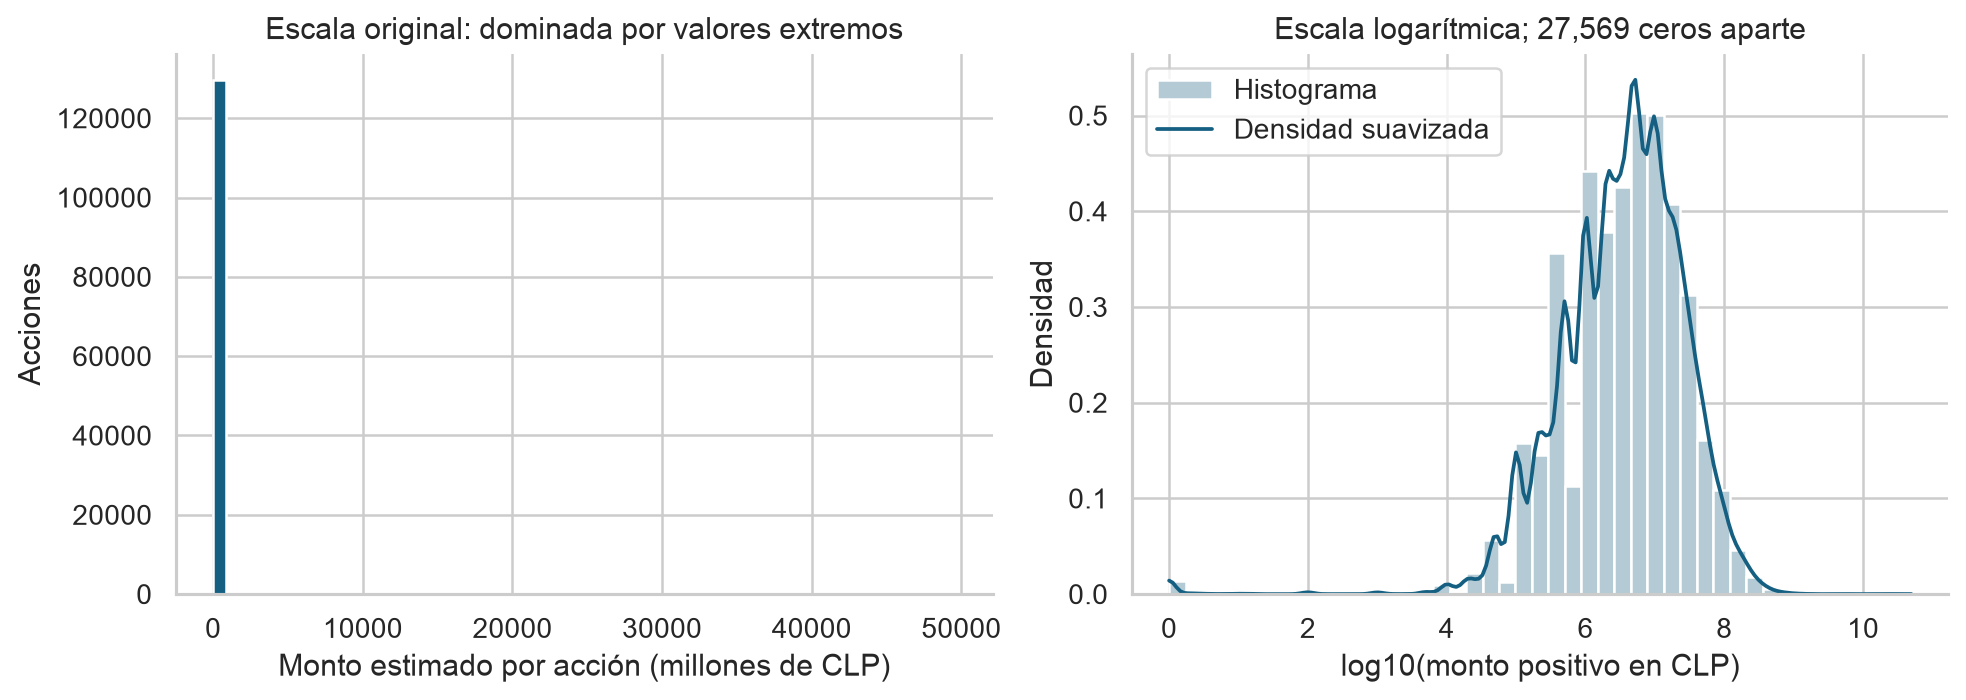

,escenario,acciones,rbd,total_estimado_clp,media_accion_clp,mediana_accion_clp,fraccion_completas,fraccion_monto_en_completas
0,Todos los registros,129726,8240,1713979868012,1.321231e+07,2000000.0,0.646331,0.679976
1,Sensibilidad: acción ≤ $1.000 millones,129707,8240,1494670497529,1.152344e+07,2000000.0,0.646311,0.694511
2,Sensibilidad: sin duplicados exactos adicionales,129722,8240,1713979867812,1.321272e+07,2000000.0,0.646336,0.679976


,DIMENSION,acciones,escuelas,estimacion_mediana_clp,estimacion_total_clp,fraccion_completas
0,Convivencia Escolar,31839,8240,1800000.0,266731510753,0.655705
1,Gestión Pedagógica,39425,8240,2000000.0,467882531245,0.653849
2,Gestión de Recursos,31083,8240,6000000.0,770677357292,0.640993
3,Liderazgo,27379,8240,750000.0,208688468722,0.630666


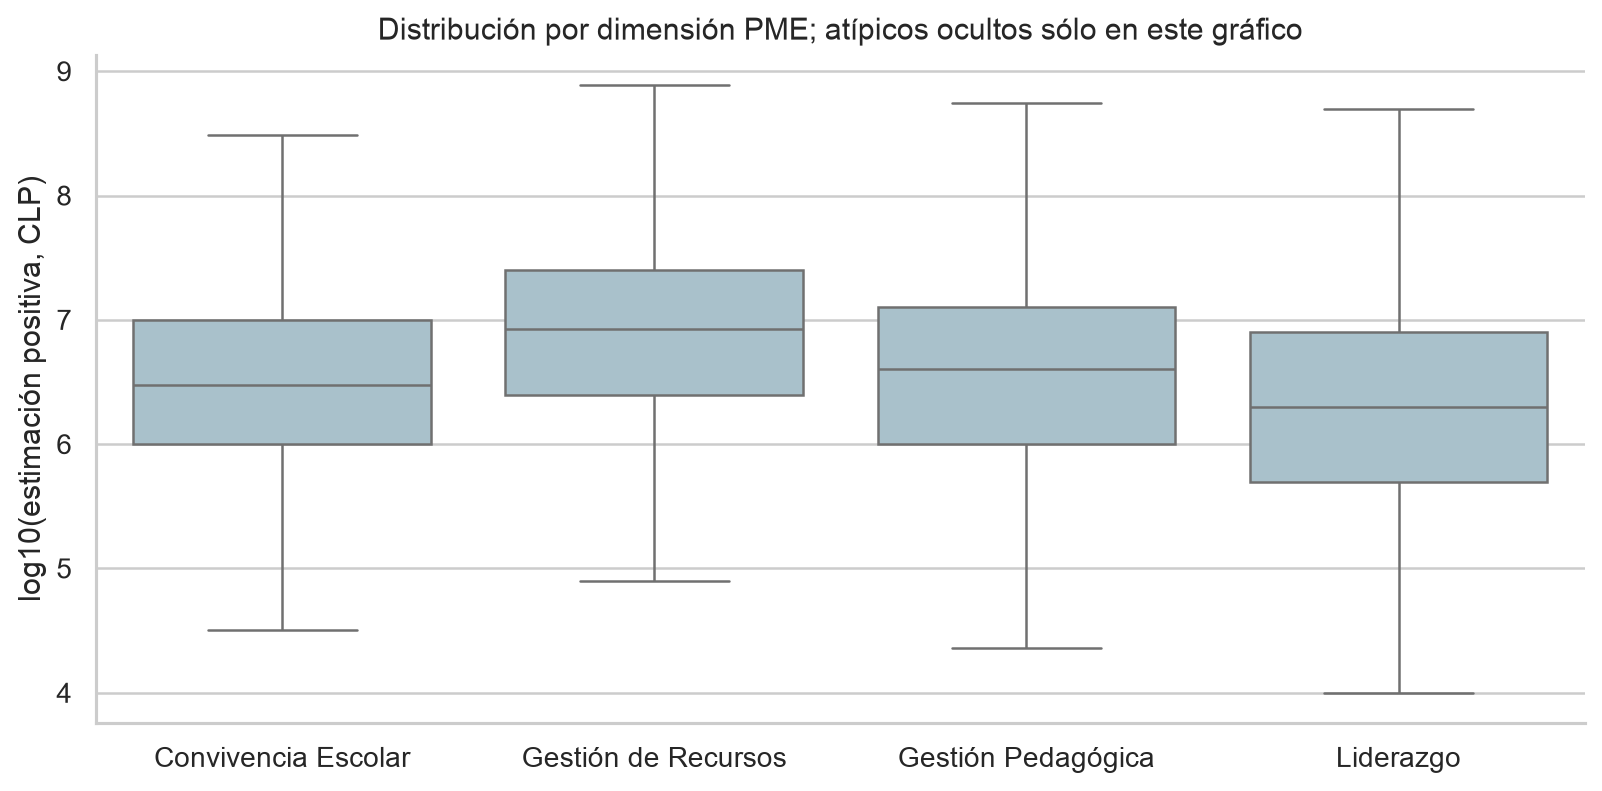

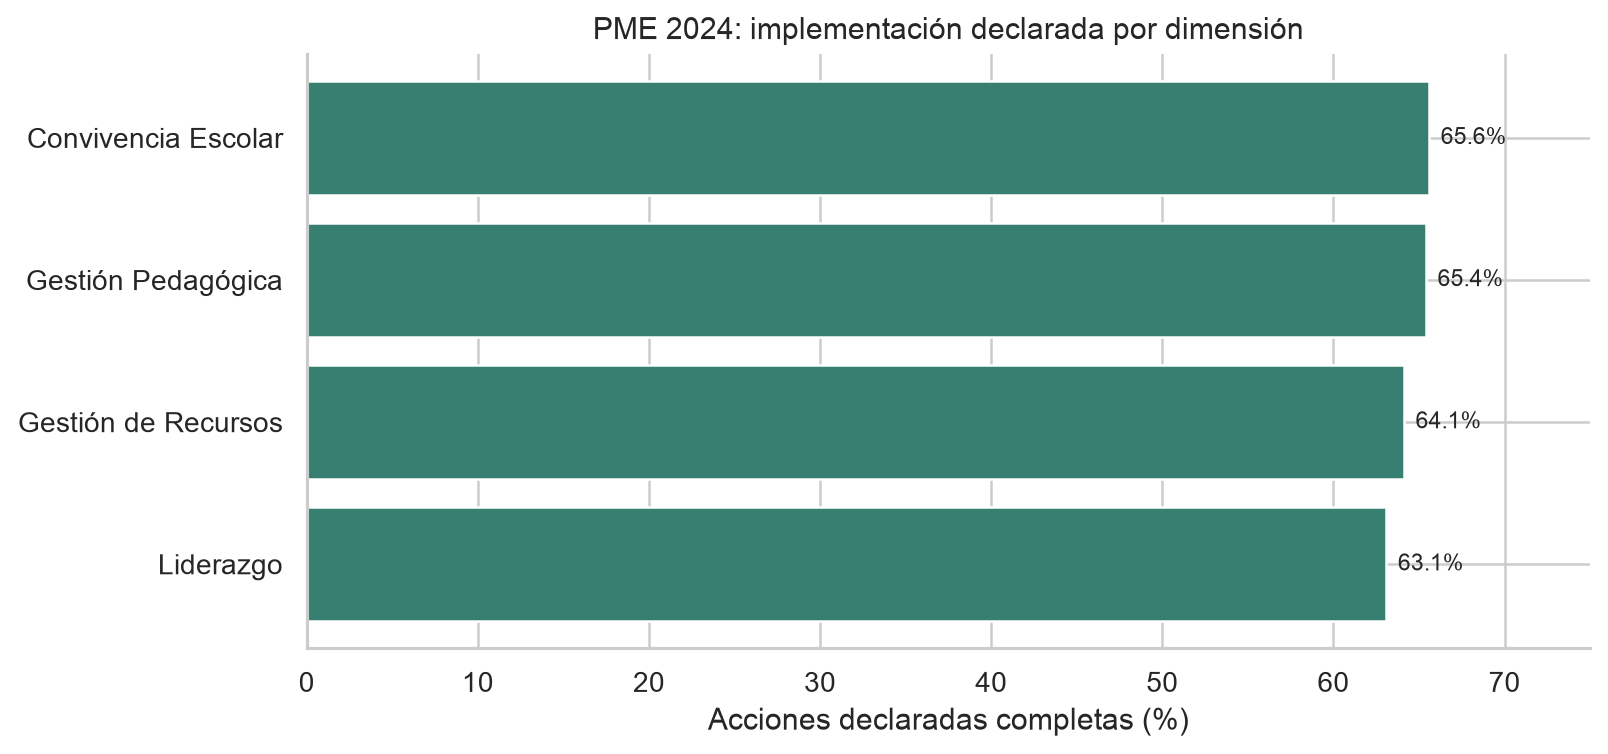

In [5]:
display(Image(filename=str(ROOT/'informes/graficos/05_pme_histograma_densidad.png')))
display(tabla('pme_sensibilidad_montos'))
display(tabla('pme_resumen_dimensiones_2024'))
display(Image(filename=str(ROOT/'informes/graficos/08_pme_dimensiones.png')))
display(Image(filename=str(ROOT/'informes/graficos/10_pme_dimensiones.png')))

## 4. Correlaciones a la unidad correcta

Una fila por RBD. Spearman ofrece una lectura menos dependiente de los extremos que Pearson. El gasto aquí es estimado. La asociación con implementación declarada es débil; no equivale a eficiencia ni a aprendizaje.

,escenario,variable_1,variable_2,n_pares,pearson,spearman
1,Todos elegibles,MAT_TOTAL,estim_total,8237,0.160296,0.795747
16,Sin escuelas con acción > $1.000 millones,MAT_TOTAL,estim_total,8221,0.756660,0.795851


,escenario,variable_1,variable_2,n_pares,pearson,spearman
13,Todos elegibles,estim_por_alumno,pct_completas,8237,0.011074,0.088917
28,Sin escuelas con acción > $1.000 millones,estim_por_alumno,pct_completas,8221,0.040153,0.088027


,dependencia,rural,n,rho_estim_por_alumno_completas
0,1,0,539,0.065089
1,1,1,237,0.135202
2,2,0,1348,0.093272
3,2,1,1780,0.042466
4,3,0,2935,0.136447
5,3,1,564,0.100844
6,5,0,35,0.111284
7,6,0,468,0.130135
8,6,1,331,-0.012184


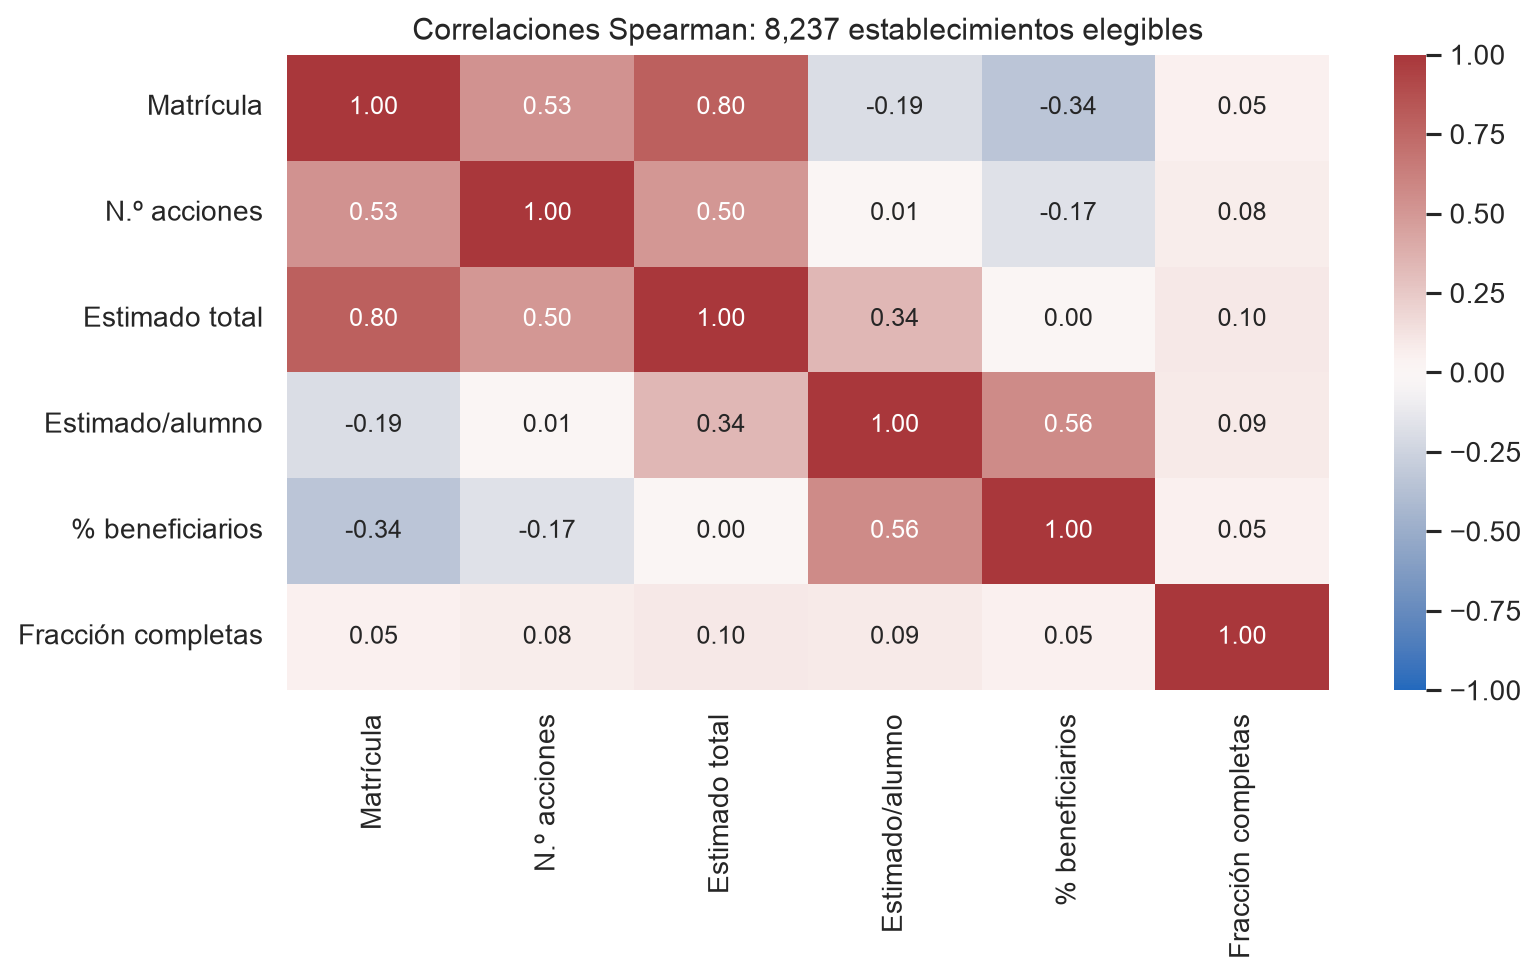

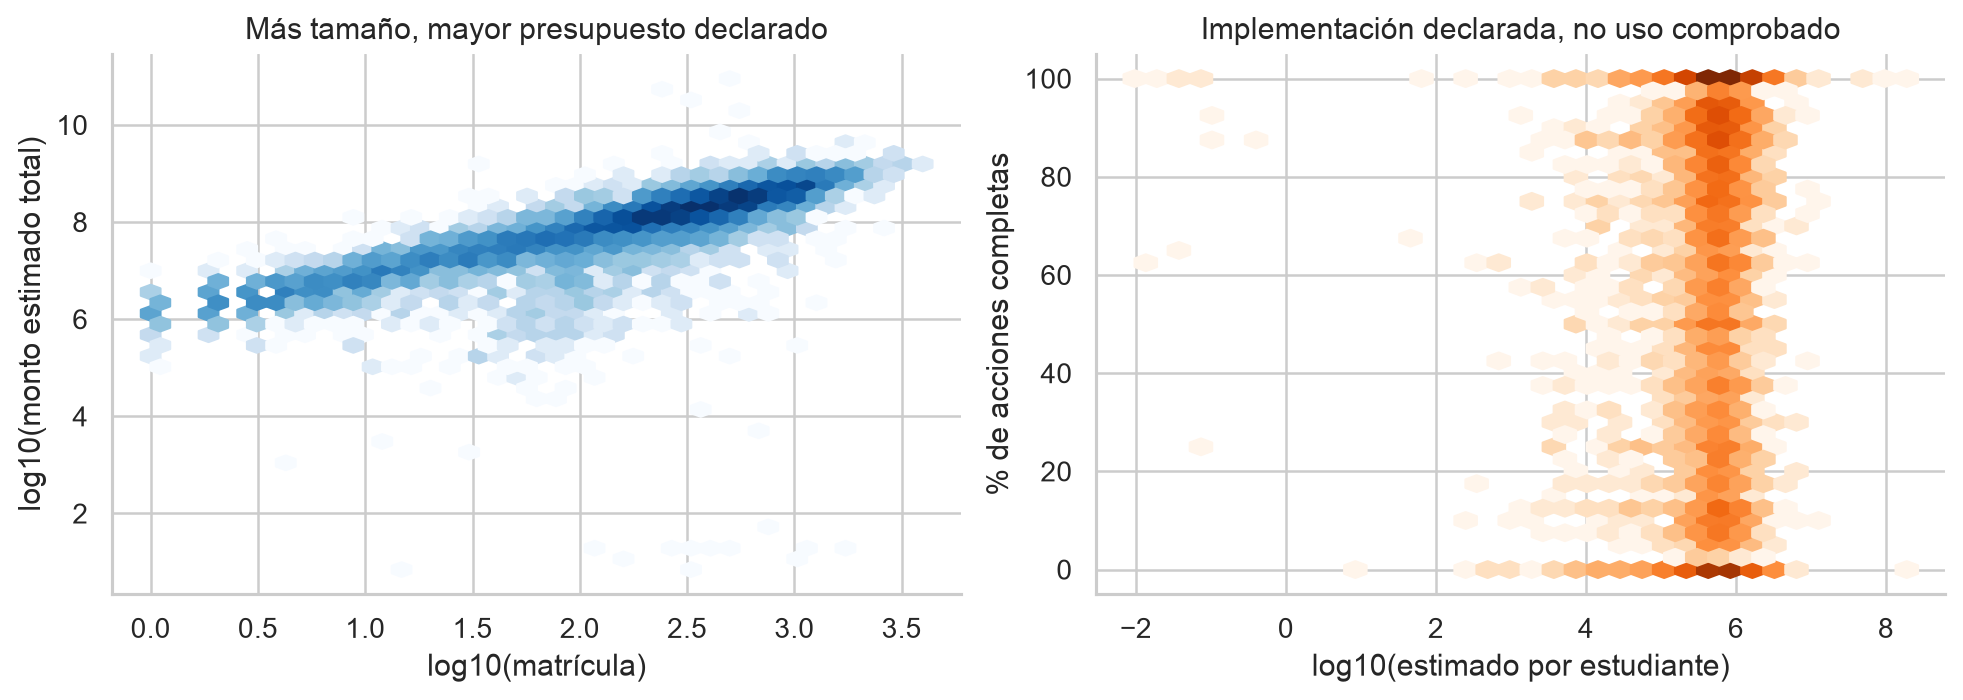

In [6]:
c = tabla('pme_correlaciones')
display(c[(c.variable_1=='MAT_TOTAL') & (c.variable_2=='estim_total')])
display(c[(c.variable_1=='estim_por_alumno') & (c.variable_2=='pct_completas')])
display(tabla('pme_correlaciones_estratificadas'))
display(Image(filename=str(ROOT/'informes/graficos/06_pme_correlaciones.png')))
display(Image(filename=str(ROOT/'informes/graficos/07_pme_relaciones.png')))

## 5. La Cisterna: fracción completa versus avance

Óscar Encalada tiene cero acciones completas, pero todas están entre 75% y 99%. Se muestran límites de avance; no se imputa un punto medio. La matrícula de 2024 sólo se usa para las estimaciones de 2024.

,RBD,NOM_RBD,MAT_TOTAL,estim_total,estim_por_alumno,pct_completas,avance_min,avance_max
0,6007,LICEO LOS ANDES,176,32000000,1.818182e+05,0.625000,81.250000,90.250000
1,6009,ESC. BASICA MOLULCO,4,1850000,4.625000e+05,0.000000,68.750000,92.750000
2,6011,ESC. BASICA MOLULCO,5,6850000,1.370000e+06,0.111111,72.222222,93.555556
3,6012,ESC. BASICA CUMCUMLLAQUE,26,30250000,1.163462e+06,0.500000,84.375000,96.375000
4,6017,ESCUELA MUNICIPAL CARÉN,3,3050000,1.016667e+06,0.000000,46.875000,70.875000
11,9693,LICEO POLITECNICO CIENCIA Y TECNOLOGIA,848,487400000,5.747642e+05,0.928571,92.928571,94.571429
12,9699,COLEGIO NACIONES UNIDAS,307,224000000,7.296417e+05,0.888889,97.222222,99.888889
13,9700,COLEGIO PALESTINO,342,136435996,3.989357e+05,0.250000,77.083333,95.083333
14,9701,LICEO POLIVALENTE OLOF PALME,449,213794000,4.761559e+05,1.000000,100.000000,100.000000
15,9703,ESCUELA ESPERANZA JOVEN,322,168729000,5.240031e+05,0.894737,93.421053,95.947368


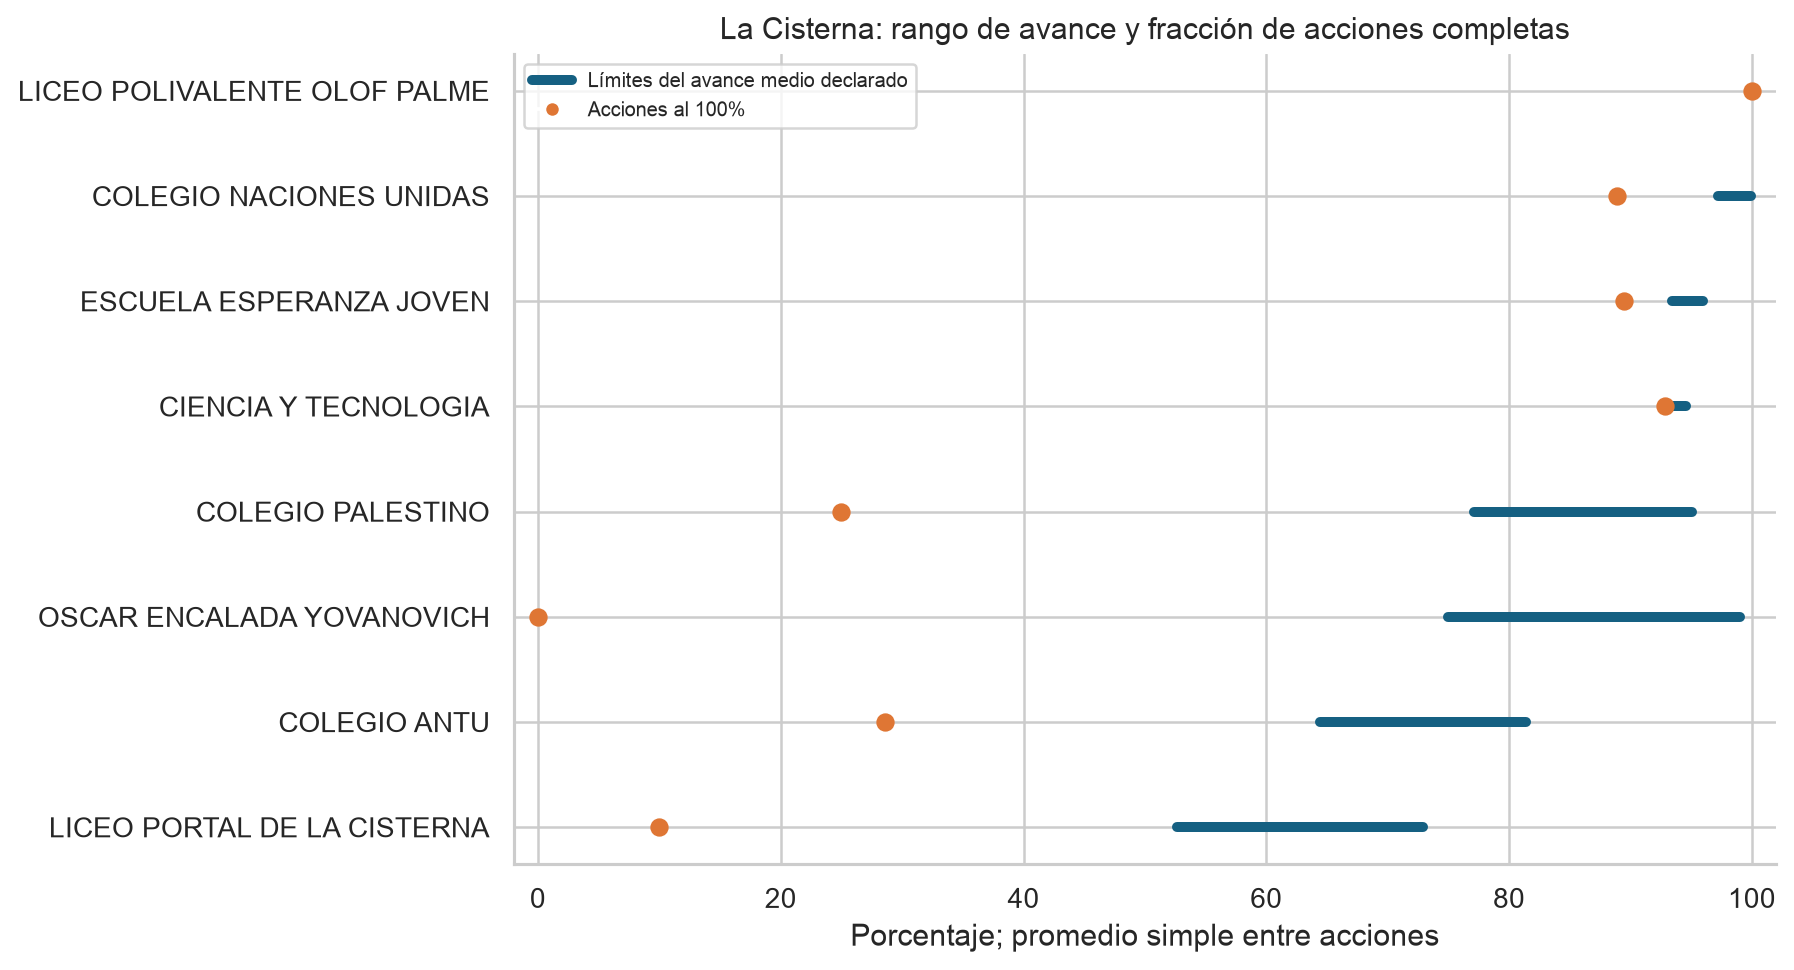

In [7]:
pilotos = tabla('pme_panel_pilotos_2024')
display(pilotos[pilotos.COD_DEPE.isin([1,2,6])][['RBD','NOM_RBD','MAT_TOTAL','estim_total','estim_por_alumno','pct_completas','avance_min','avance_max']])
display(Image(filename=str(ROOT/'informes/graficos/09_pme_rangos_la_cisterna.png')))

## 6. Compras y observaciones de Melipeuco

No es una muestra aleatoria nacional: es el universo que definió la auditoría. Los valores son pesos históricos. El histograma por lote y el ponderado por unidades responden a preguntas distintas.

Partidas: 29 Unidades: 776 Monto sumado: 176164030


,anio,lotes,unidades,valor_clp
0,2020,8,156,27576133
1,2021,20,619,147757907
2,2022,1,1,829990


,fondo,cantidad,valor_clp
0,SEP,500,123193610
1,SEP administración central,9,9269085
2,FAEP sin año,15,10969600
3,FAEP 2020,47,3871260
4,FAEP 2019,175,24885874
5,Movámonos 2020,30,3974600


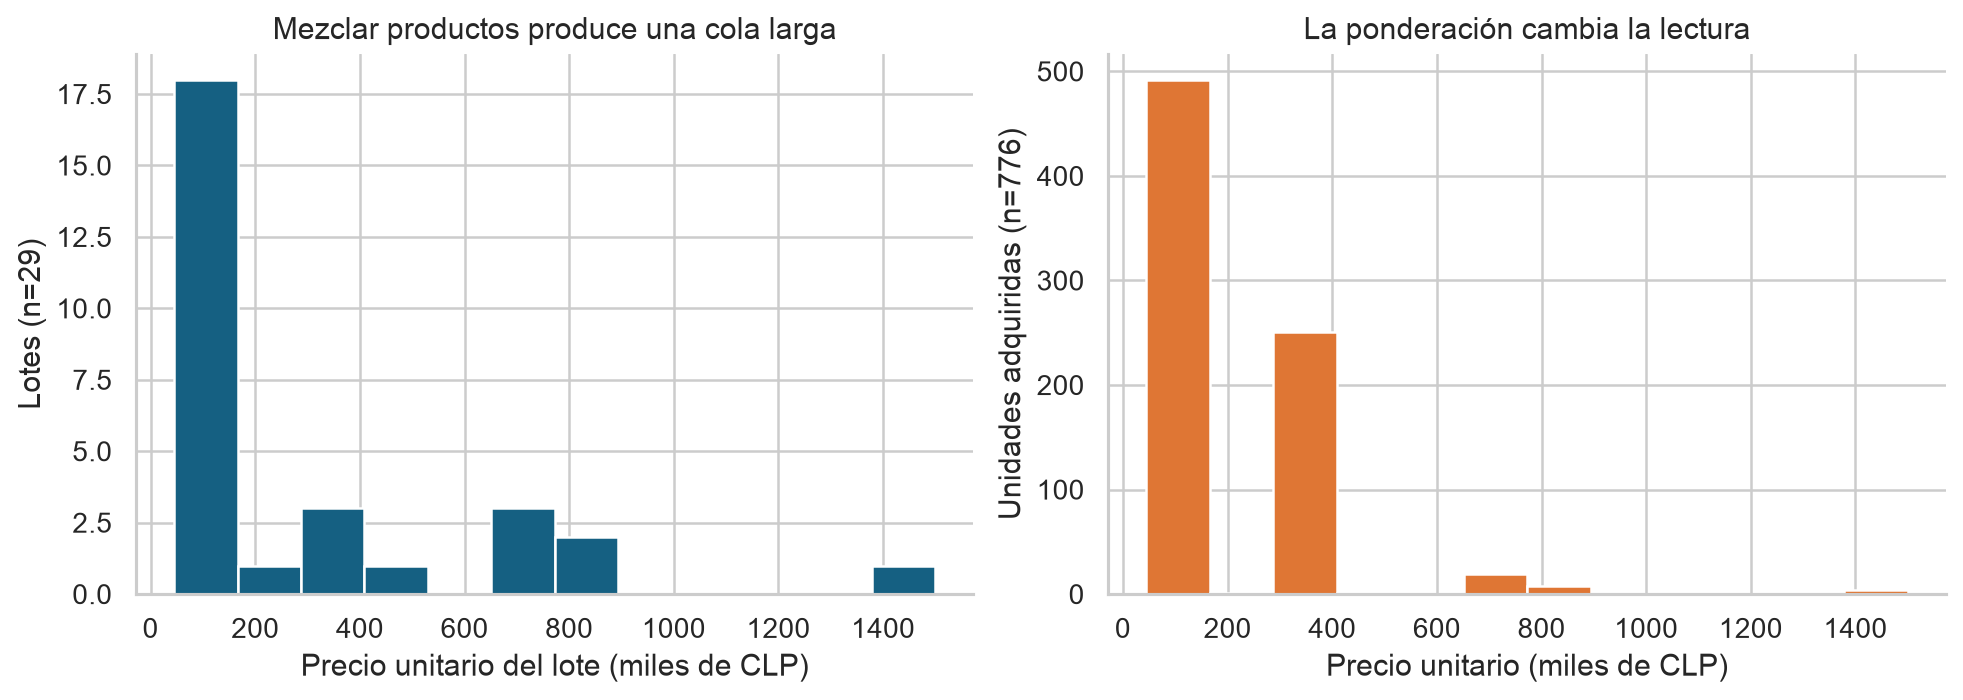

In [8]:
compras=tabla('cgr_compras_lotes')
no_habidos=tabla('cgr_no_habidos')
print('Partidas:',len(compras),'Unidades:',compras.cantidad.sum(),'Monto sumado:',compras.valor_clp.sum())
display(tabla('cgr_resumen_anio'))
display(tabla('cgr_fuentes_financiamiento'))
display(Image(filename=str(ROOT/'informes/graficos/01_precios_lotes_unidades.png')))

Tasa física: 0.8092783505154639 Tasa monetaria: 0.77430891410868


,equipos,valor_clp
observacion,,
10.a,625,136000454
10.b,2,164734
10.c,1,240190


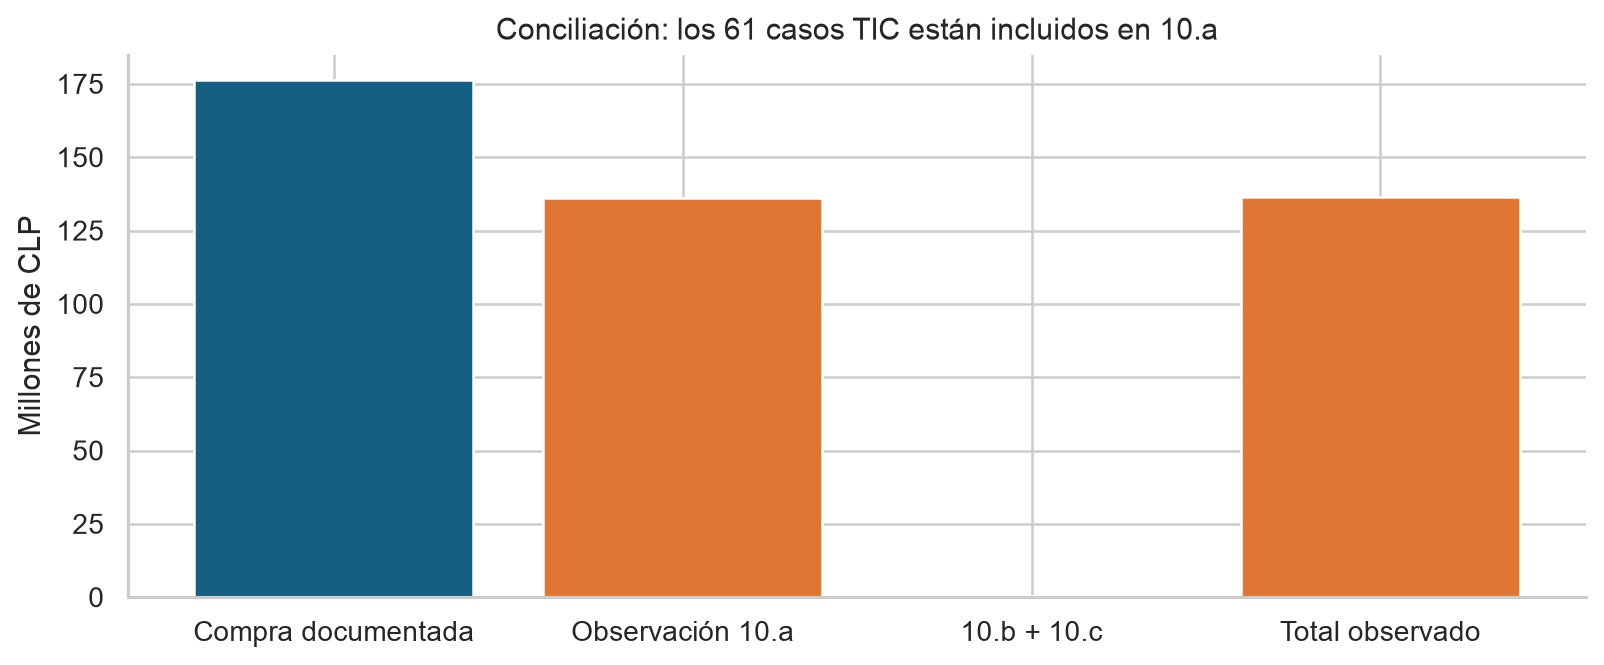

,familia,adquiridos,compra_clp,no_habidos,valor_no_habido_clp,tasa_no_habidos
0,Asus portátil,15,10969600,5.0,3656535.0,0.333333
1,Dell portátil,7,6037001,0.0,0.0,0.000000
2,HP AIO Ryzen,4,2846620,0.0,0.0,0.000000
3,HP AIO i3,1,422485,0.0,0.0,0.000000
4,Huawei T3,100,8236713,19.0,1564973.0,0.190000
5,Impresora Epson,1,240190,1.0,240190.0,1.000000
6,Lenovo AIO,1,829990,0.0,0.0,0.000000
7,Lenovo M8,4,606176,4.0,606176.0,1.000000
8,Lenovo P11 + teclado/lápiz,250,87499808,231.0,80849769.0,0.924000
9,Mlab 7,29,1304158,29.0,1304159.0,1.000000


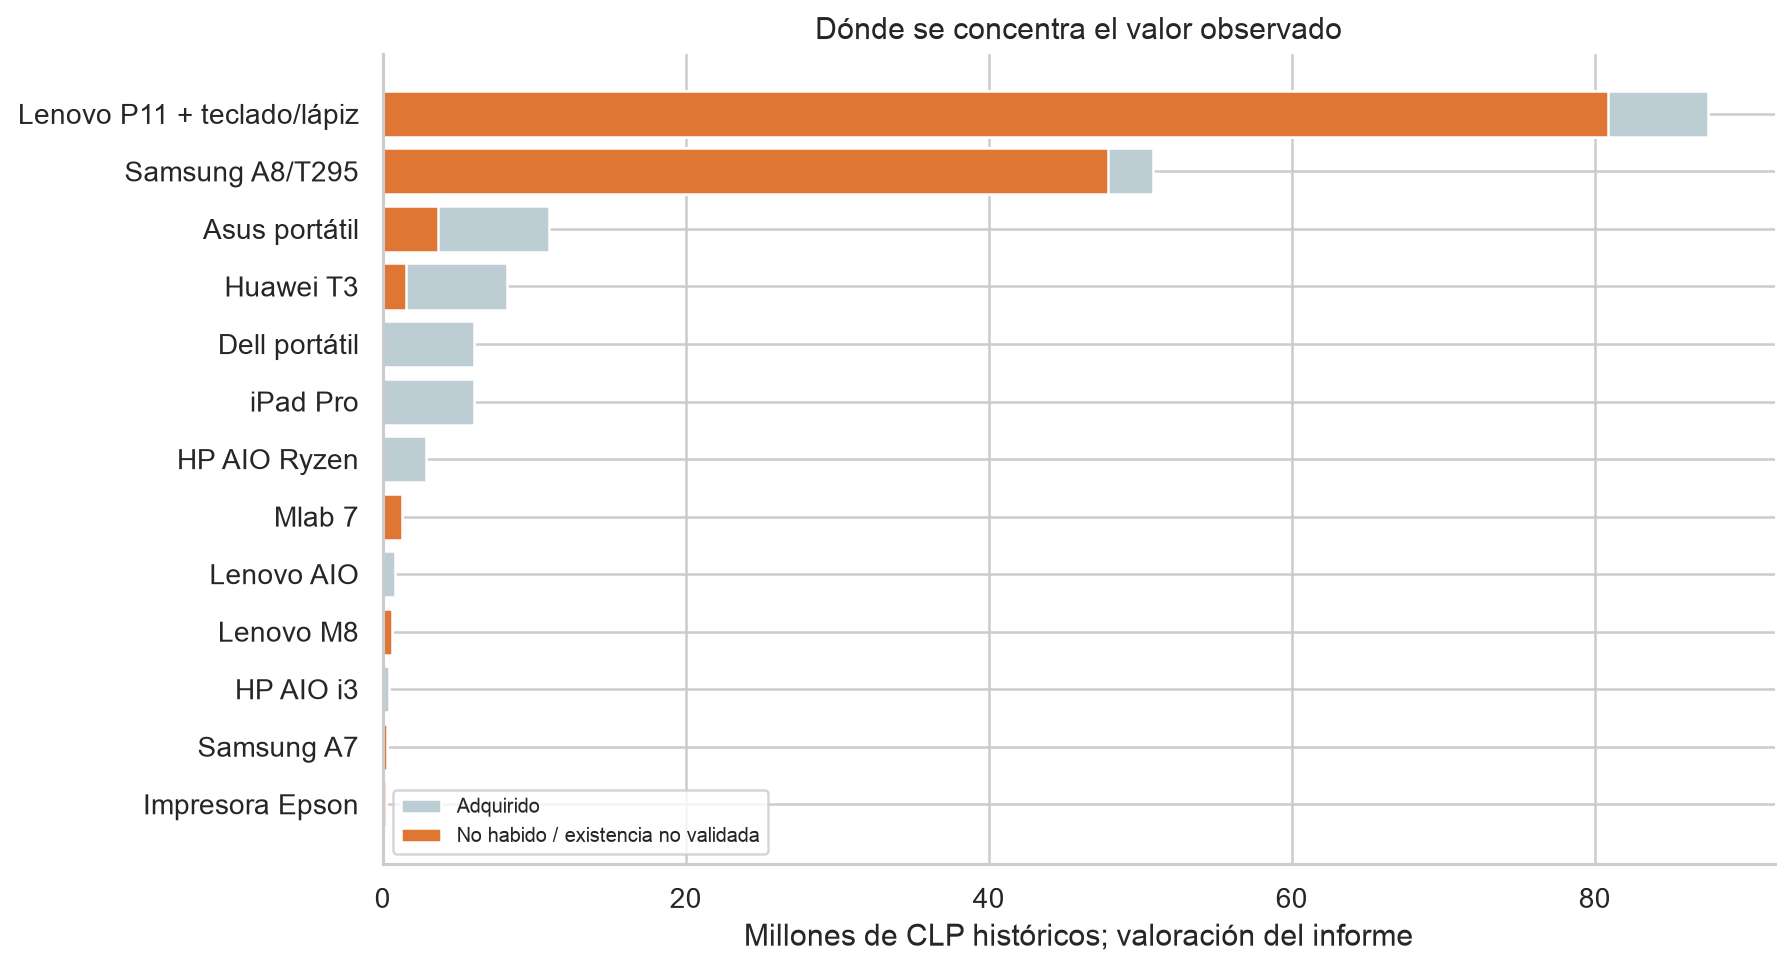

In [9]:
display(no_habidos.groupby('observacion').agg(equipos=('id_fila','size'),valor_clp=('valor_clp','sum')))
print('Tasa física:',len(no_habidos)/776,'Tasa monetaria:',no_habidos.valor_clp.sum()/176164029)
display(Image(filename=str(ROOT/'informes/graficos/04_conciliacion_caso.png')))
display(tabla('cgr_resumen_modelo'))
display(Image(filename=str(ROOT/'informes/graficos/02_valor_por_modelo.png')))

## 7. Cruce de evidencia y asignación incierta

El cruce por factura y serie encuentra 476 registros con comodato entre los no habidos. Los 18 equipos sin distribución por escuela no se asignan al DEM por mera igualdad de cantidad. Los intervalos por escuela son límites marginales, no intervalos de confianza.

Coincidencias: 476 Valor: 106512158 Proporción del anexo 5: 0.7933333333333333


,dependencia,no_habidos_min,no_habidos_max,adquiridos,tasa_min,tasa_max
0,Carén,9,14,14,0.642857,1.000000
1,Cumcumllaque,48,52,52,0.923077,1.000000
2,DEM,0,18,27,0.000000,0.666667
3,Fundo Molulco,9,10,10,0.900000,1.000000
4,Los Andes,184,184,206,0.893204,0.893204
5,Molulco,4,4,4,1.000000,1.000000
6,Volcán Llaima,356,356,463,0.768898,0.768898


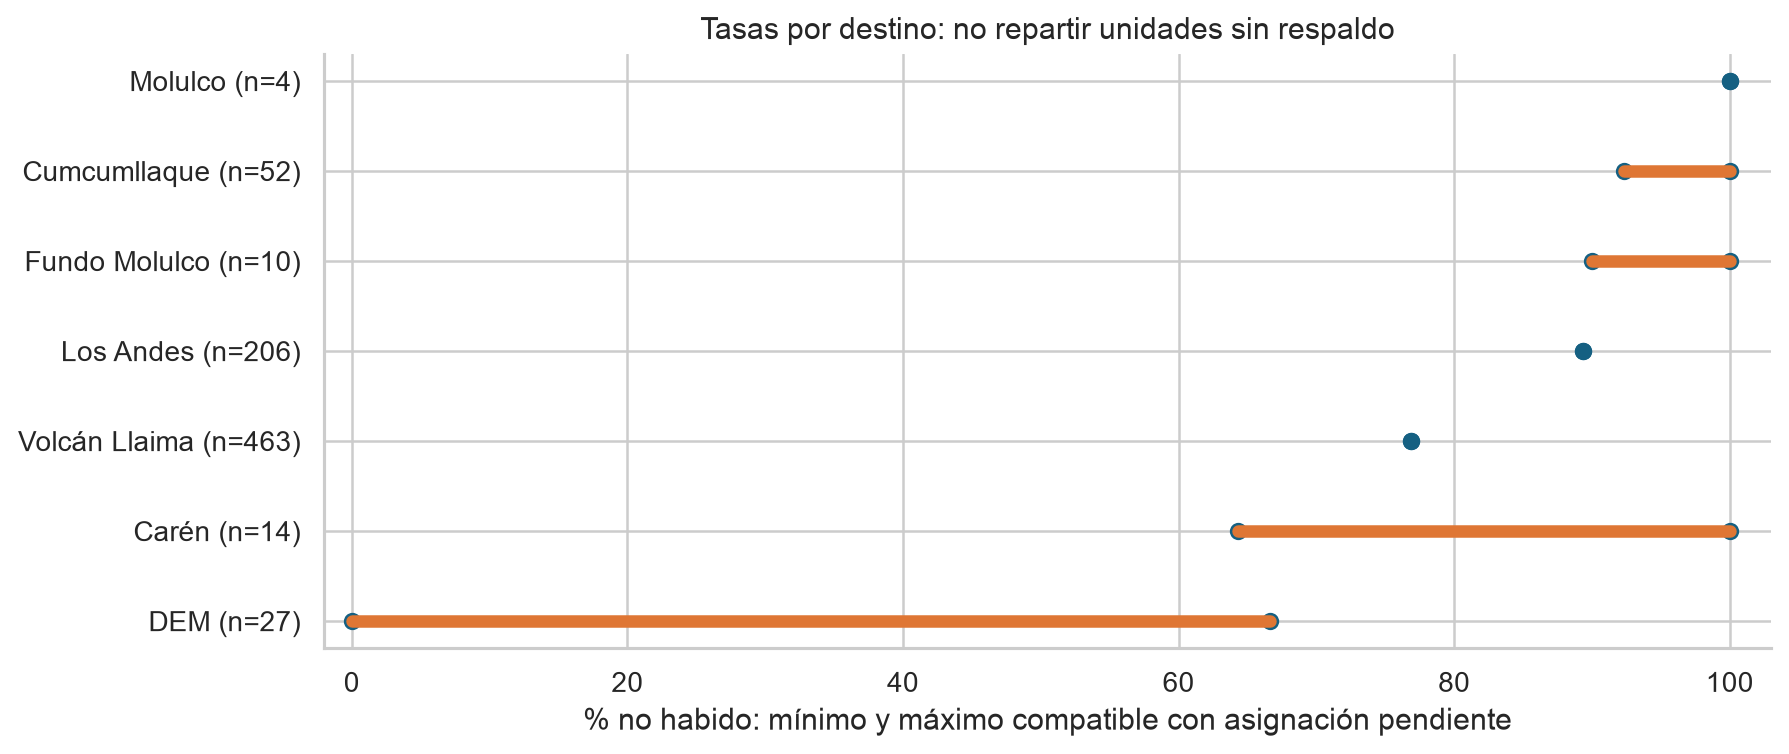

In [10]:
cruce=tabla('cgr_interseccion_comodato_no_habidos')
print('Coincidencias:',len(cruce),'Valor:',cruce.valor_clp.sum(),'Proporción del anexo 5:',len(cruce)/600)
display(tabla('cgr_limites_por_dependencia'))
display(Image(filename=str(ROOT/'informes/graficos/03_limites_por_destino.png')))

## 8. Controles y conclusión

La diferencia de $1 se conserva. La duplicidad TIC de 61 entregas está incluida en el total observado y no se suma. Se requiere seguimiento para saber qué se recuperó, qué bajas fueron acreditadas y cuál es la pérdida definitiva. Los montos PME y SIMCE no pueden reemplazar esa prueba. Ver informe y solicitudes documentales para descargos y fuentes.

In [11]:
import runpy
runpy.run_path(str(ROOT/'scripts/verificar.py'),run_name='__main__')
display(tabla('verificaciones'))

24 controles de integridad y procedencia aprobados.


,control,resultado
0,SHA256: cgr_melipeuco_43_2024,OK
1,SHA256: cgr_reporte_hallazgos_2024_2025,OK
2,SHA256: directorio_2024,OK
3,SHA256: directorio_2021,OK
4,SHA256: pme_implementacion_2024,OK
5,SHA256: catalogo_pme,OK
6,SHA256: catalogo_directorio,OK
7,"Anexo 1: 29 partidas, 776 unidades",OK
8,Diferencia de $1 preservada,OK
9,Anexo 4: 625 filas y $136.000.454,OK


## 9. ¿Estuvo bien invertido?

La tasa de bienes no habidos mide custodia histórica, no eficacia ni pérdida definitiva. Las cuatro categorías de gasto se asignarán a partidas pagadas con documentos de legalidad, objetivo previo, entrega/uso y costo comparable; los casos sin esa evidencia quedan pendientes. Melipeuco presenta una señal fiscalizada de potencial irregularidad en custodia, con seguimiento aún desconocido. SIMCE posterior no demuestra por sí solo impacto de la compra. El marco reproducible está en informes/Marco_evaluacion_gasto.md.